<a href="https://colab.research.google.com/github/adnanaemir04/Makine-Ogrenmesi-Ara-Odev/blob/master/Makine%C3%96%C4%9FrenmesiMediumYaz%C4%B1s%C4%B1%C3%96devi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("kredi_risk_veri_seti.csv")

In [4]:
print("Veri setinin boyutu:")
print(df.shape)


Veri setinin boyutu:
(1000, 15)


In [6]:
print("\nSütunlar:")
df.columns.tolist()


Sütunlar:


['musteri_id',
 'yas',
 'aylik_gelir_TL',
 'calisma_suresi_yil',
 'kredi_tutari_TL',
 'kredi_vadesi_ay',
 'kredi_gecmisi_ay',
 'mevcut_borc_TL',
 'aylik_gider_TL',
 'ev_sahipligi',
 'calisma_durumu',
 'kredi_amaci',
 'odeme_gecmisi',
 'onceki_takip_sayisi',
 'kredi_riski']

In [7]:

print("\nVeri tipleri:")
df.dtypes



Veri tipleri:


,0
musteri_id,object
yas,int64
aylik_gelir_TL,float64
calisma_suresi_yil,float64
kredi_tutari_TL,int64
kredi_vadesi_ay,int64
kredi_gecmisi_ay,int64
mevcut_borc_TL,float64
aylik_gider_TL,int64
ev_sahipligi,object


In [8]:
print("\nİlk 5 satır:")
display(df.head())


İlk 5 satır:


,musteri_id,yas,aylik_gelir_TL,calisma_suresi_yil,kredi_tutari_TL,kredi_vadesi_ay,kredi_gecmisi_ay,mevcut_borc_TL,aylik_gider_TL,ev_sahipligi,calisma_durumu,kredi_amaci,odeme_gecmisi,onceki_takip_sayisi,kredi_riski
0,M00001,59,50216.0,13.2,58922,36,475,49738.0,10266,Ev Sahibi,Serbest,Arac,Iyi,0,Risksiz
1,M00002,49,82357.0,17.2,74302,36,207,0.0,11631,Kira,Tam Zamanli,Tuketici,Iyi,0,Risksiz
2,M00003,35,60680.0,4.8,16713,24,219,57621.0,18823,Ev Sahibi,Tam Zamanli,Ev,Iyi,0,Risksiz
3,M00004,63,39132.0,14.5,82260,48,443,50203.0,5000,Aile Yaninda,Yari Zamanli,Isletme,Kotu,0,Riskli
4,M00005,28,66622.0,6.8,39119,72,66,21724.0,31388,Ev Sahibi,Tam Zamanli,Isletme,Kotu,1,Riskli


In [9]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Eksik Değer Sayısı": missing_values,
    "Eksik Değer Oranı (%)": (missing_values / len(df) * 100).round(2)
})

missing_table = missing_table.sort_values(
    by="Eksik Değer Sayısı",
    ascending=False
)

display(missing_table)

,Eksik Değer Sayısı,Eksik Değer Oranı (%)
aylik_gelir_TL,15,1.5
calisma_suresi_yil,15,1.5
mevcut_borc_TL,15,1.5
odeme_gecmisi,15,1.5
kredi_tutari_TL,0,0.0
yas,0,0.0
musteri_id,0,0.0
kredi_gecmisi_ay,0,0.0
kredi_vadesi_ay,0,0.0
ev_sahipligi,0,0.0


In [11]:
print(df["kredi_riski"].value_counts())
print(
    df["kredi_riski"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

kredi_riski
Riskli     652
Risksiz    348
Name: count, dtype: int64
kredi_riski
Riskli     65.2
Risksiz    34.8
Name: proportion, dtype: float64


In [13]:
df_model = df.drop(columns=["musteri_id"]).copy()

In [14]:
# ID sütununu kaldır
df_model = df.drop(columns=["musteri_id"]).copy()

# Sayısal sütunlardaki eksik değerleri medyan ile doldur
sayisal_sutunlar = df_model.select_dtypes(include=["int64", "float64"]).columns

for sutun in sayisal_sutunlar:
    df_model[sutun] = df_model[sutun].fillna(df_model[sutun].median())

# Kategorik sütunlardaki eksik değerleri mod ile doldur
kategorik_sutunlar = df_model.select_dtypes(include=["object"]).columns

for sutun in kategorik_sutunlar:
    df_model[sutun] = df_model[sutun].fillna(df_model[sutun].mode()[0])

print(df_model.isnull().sum())

yas                    0
aylik_gelir_TL         0
calisma_suresi_yil     0
kredi_tutari_TL        0
kredi_vadesi_ay        0
kredi_gecmisi_ay       0
mevcut_borc_TL         0
aylik_gider_TL         0
ev_sahipligi           0
calisma_durumu         0
kredi_amaci            0
odeme_gecmisi          0
onceki_takip_sayisi    0
kredi_riski            0
dtype: int64


In [15]:
# Kategorik değişkenleri One-Hot Encoding ile sayısal forma dönüştür
kategorik_sutunlar = df_model.select_dtypes(include=["object"]).columns

df_model = pd.get_dummies(
    df_model,
    columns=kategorik_sutunlar,
    drop_first=True,
    dtype=int
)

df_model.head()

,yas,aylik_gelir_TL,calisma_suresi_yil,kredi_tutari_TL,kredi_vadesi_ay,kredi_gecmisi_ay,mevcut_borc_TL,aylik_gider_TL,onceki_takip_sayisi,ev_sahipligi_Ev Sahibi,...,calisma_durumu_Tam Zamanli,calisma_durumu_Yari Zamanli,kredi_amaci_Egitim,kredi_amaci_Ev,kredi_amaci_Isletme,kredi_amaci_Tatil,kredi_amaci_Tuketici,odeme_gecmisi_Kotu,odeme_gecmisi_Orta,kredi_riski_Risksiz
0,59,50216.0,13.2,58922,36,475,49738.0,10266,0,1,...,0,0,0,0,0,0,0,0,0,1
1,49,82357.0,17.2,74302,36,207,0.0,11631,0,0,...,1,0,0,0,0,0,1,0,0,1
2,35,60680.0,4.8,16713,24,219,57621.0,18823,0,1,...,1,0,0,1,0,0,0,0,0,1
3,63,39132.0,14.5,82260,48,443,50203.0,5000,0,0,...,0,1,0,0,1,0,0,1,0,0
4,28,66622.0,6.8,39119,72,66,21724.0,31388,1,1,...,1,0,0,0,1,0,0,1,0,0


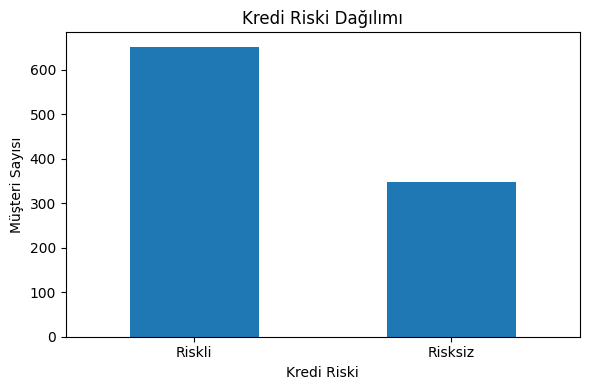

In [16]:
plt.figure(figsize=(6, 4))

df["kredi_riski"].value_counts().plot(kind="bar")

plt.title("Kredi Riski Dağılımı")
plt.xlabel("Kredi Riski")
plt.ylabel("Müşteri Sayısı")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

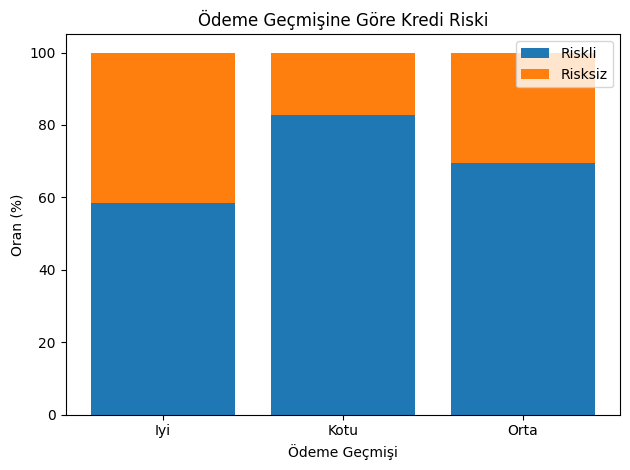

In [18]:
import matplotlib.pyplot as plt

risk_oranlari = df.groupby("odeme_gecmisi")["kredi_riski"].value_counts(normalize=True).unstack() * 100

x = range(len(risk_oranlari))

plt.bar(x, risk_oranlari["Riskli"], label="Riskli")
plt.bar(x, risk_oranlari["Risksiz"], bottom=risk_oranlari["Riskli"], label="Risksiz")

plt.xticks(x, risk_oranlari.index)
plt.xlabel("Ödeme Geçmişi")
plt.ylabel("Oran (%)")
plt.title("Ödeme Geçmişine Göre Kredi Riski")
plt.legend()

plt.tight_layout()
plt.show()

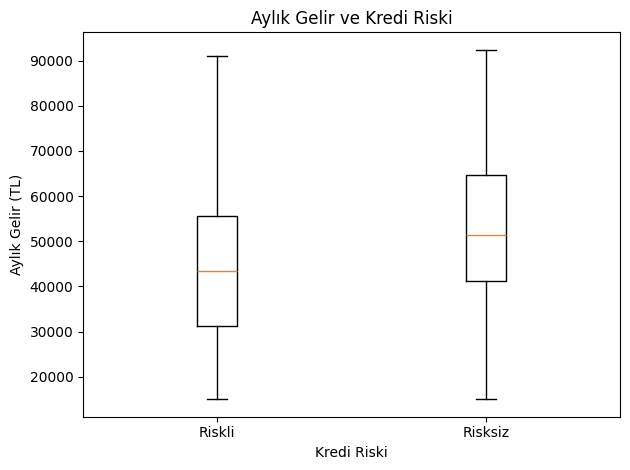

In [19]:
import matplotlib.pyplot as plt

riskli = df[df["kredi_riski"] == "Riskli"]["aylik_gelir_TL"].dropna()
risksiz = df[df["kredi_riski"] == "Risksiz"]["aylik_gelir_TL"].dropna()

plt.boxplot(
    [riskli, risksiz],
    labels=["Riskli", "Risksiz"]
)

plt.xlabel("Kredi Riski")
plt.ylabel("Aylık Gelir (TL)")
plt.title("Aylık Gelir ve Kredi Riski")

plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

# Hedef değişken
y = df["kredi_riski"].map({
    "Risksiz": 0,
    "Riskli": 1
})

# Özellikler
X = df.drop(
    columns=["musteri_id", "kredi_riski"]
).copy()

# Kategorik değişkenleri One-Hot Encoding
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

# Eksik değerleri doldur
X = X.fillna(X.median())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 21)
X_test: (200, 21)
y_train: (800,)
y_test: (200,)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Modeller
logistic_model = LogisticRegression(max_iter=1000)
decision_tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

# Modelleri eğit
logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

# Tahminler
y_pred_logistic = logistic_model.predict(X_test)
y_pred_tree = decision_tree_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)

# Olasılık tahminleri (ROC-AUC için)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("3 model de başarıyla eğitildi.")

3 model de başarıyla eğitildi.


In [27]:
sonuclar = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

sonuclar.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.65,0.700,0.808,0.750,0.698
1,Decision Tree,0.58,0.655,0.746,0.698,0.623
2,Random Forest,0.64,0.675,0.862,0.757,0.668


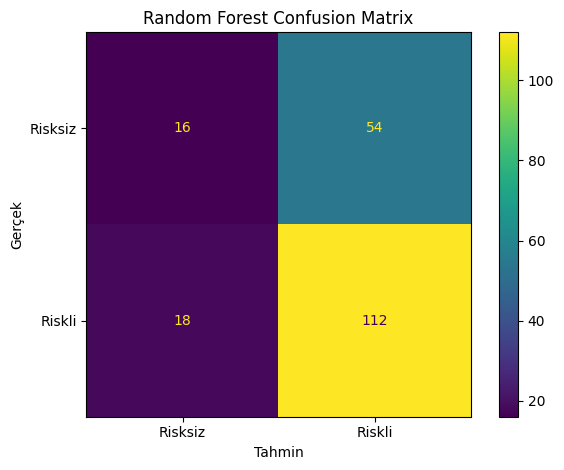

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Risksiz", "Riskli"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.tight_layout()
plt.show()

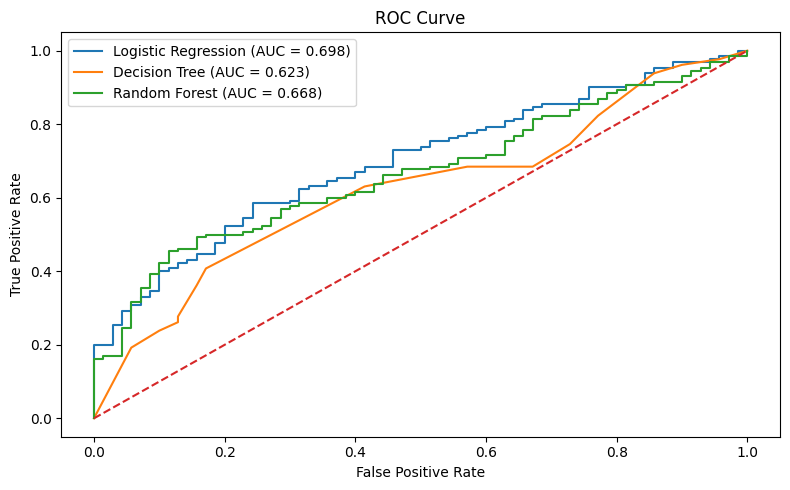

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 5))

plt.plot(fpr_logistic, tpr_logistic, label="Logistic Regression (AUC = 0.698)")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree (AUC = 0.623)")
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = 0.668)")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

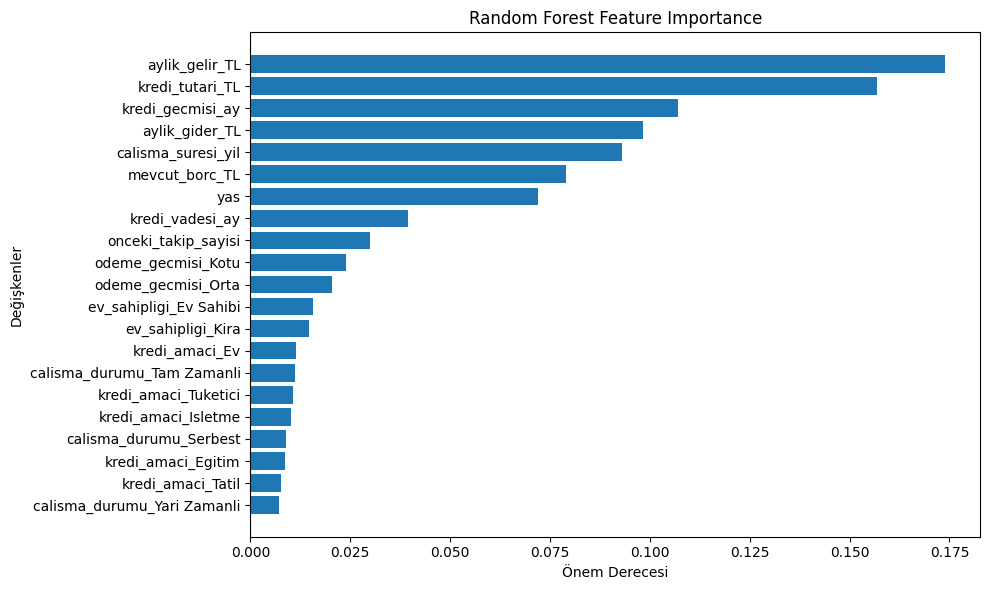

aylik_gelir_TL         0.173948
kredi_tutari_TL        0.156932
kredi_gecmisi_ay       0.107003
aylik_gider_TL         0.098389
calisma_suresi_yil     0.093082
mevcut_borc_TL         0.079004
yas                    0.071979
kredi_vadesi_ay        0.039334
onceki_takip_sayisi    0.029914
odeme_gecmisi_Kotu     0.023993
dtype: float64


In [30]:
import matplotlib.pyplot as plt
import pandas as pd

onemler = pd.Series(
    random_forest_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(onemler.index, onemler.values)
plt.xlabel("Önem Derecesi")
plt.ylabel("Değişkenler")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(onemler.head(10))